In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Survey Completeness & Overlap Analysis

Comparing three survey waves (`real_data_1.csv`, `real_data_2.csv`, `real_data_3.csv`).

**What's measured:**
1. Response volume per survey.
2. Teamwise **non-response** — how many known team members did NOT fill each survey, per team.
3. Overlap / attrition — who filled which combinations.

**Respondent identifier.** `Rater` is unique within each survey; used as the respondent ID across surveys.

**Team lookup.** The `team` column in each CSV is the anonymous team number. It's joined to `Anon_link_to_Team_name_v01.xlsx` to attach team names and rooms. Team 27 appears in the surveys but is absent from the mapping — it's labelled `(no mapping)` in outputs.

**Definition of "did not fill".** The surveys don't give us a true team roster, so each team's denominator is defined as the set of distinct respondents ever seen from that team across all three waves. "Did not fill Survey N" therefore means: a person we know belongs to this team (because they answered at least one wave) was missing from wave N. This under-counts any team member who never answered any wave.

## 1. Setup & load

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib_venn import venn3

plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

PATHS = {
    'S1': '/content/drive/MyDrive/Real_data/real_data_1.csv',
    'S2': '/content/drive/MyDrive/Real_data/real_data_2.csv',
    'S3': '/content/drive/MyDrive/Real_data/real_data_3.csv',
}
MAPPING_PATH = '/content/drive/MyDrive/Real_data/Anon link to Team name v01.xlsx'

surveys = {k: pd.read_csv(v) for k, v in PATHS.items()}
for name, df in surveys.items():
    print(f'{name}: {df.shape[0]} rows, {df.shape[1]} columns')

S1: 89 rows, 27 columns
S2: 74 rows, 21 columns
S3: 67 rows, 23 columns


### Load team mapping

In [3]:
mapping_raw = pd.read_excel(MAPPING_PATH, sheet_name='Hack27 Teams')
mapping = (mapping_raw[['Anon Team', 'Team Name', 'Team Room']]
           .dropna(subset=['Anon Team'])
           .copy())
mapping['Anon Team'] = mapping['Anon Team'].astype(int)
mapping['Team Name'] = mapping['Team Name'].fillna('(no name)').astype(str).str.strip()
mapping['Team Room'] = mapping['Team Room'].fillna('(no room)').astype(str).str.strip()
mapping = mapping.rename(columns={'Anon Team': 'team'}).drop_duplicates('team')
mapping.head()

,team,Team Name,Team Room
0,1,Woodmynd,1A
1,2,NDA_null,1B
2,3,Collective Voice,1C
3,4,PaNDA,1D
4,5,NU-Shift,1E


## 2. Build a unified respondent table

One row per `Rater`. Each row has three boolean flags (`in_S1`, `in_S2`, `in_S3`), the team number, and the joined team name / room.

In [4]:
slim = {}
for name, df in surveys.items():
    s = df[['Rater', 'team']].drop_duplicates('Rater').copy()
    s[f'in_{name}'] = True
    s = s.rename(columns={'team': f'team_{name}'})
    slim[name] = s

master = slim['S1'].merge(slim['S2'], on='Rater', how='outer').merge(slim['S3'], on='Rater', how='outer')
for col in ['in_S1', 'in_S2', 'in_S3']:
    master[col] = master[col].fillna(False).astype(bool)

master['team'] = (master['team_S1']
                  .combine_first(master['team_S2'])
                  .combine_first(master['team_S3'])
                  .astype('Int64'))
master = master[['Rater', 'team', 'in_S1', 'in_S2', 'in_S3']]

master = master.merge(mapping, on='team', how='left')
master['Team Name'] = master['Team Name'].fillna('(no mapping)')
master['Team Room'] = master['Team Room'].fillna('(no mapping)')
master['team_label'] = master.apply(
    lambda r: f"T{int(r['team'])} \u2014 {r['Team Name']} ({r['Team Room']})", axis=1
)

print(f'Total distinct respondents across all three surveys: {len(master)}')
unmapped = sorted(master.loc[master['Team Name'] == '(no mapping)', 'team'].dropna().unique().tolist())
if unmapped:
    print(f'Teams in surveys but NOT in mapping file: {unmapped}')
master.head()

Total distinct respondents across all three surveys: 123
Teams in surveys but NOT in mapping file: [27]


/tmp/ipykernel_2087/1042029064.py:10: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  master[col] = master[col].fillna(False).astype(bool)
/tmp/ipykernel_2087/1042029064.py:10: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  master[col] = master[col].fillna(False).astype(bool)
/tmp/ipykernel_2087/1042029064.py:10: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downc

,Rater,team,in_S1,in_S2,in_S3,Team Name,Team Room,team_label
0,-3500008,35,False,False,True,Rock 'n' Rolls Royce,6F,T35 — Rock 'n' Rolls Royce (6F)
1,-3500007,35,True,True,True,Rock 'n' Rolls Royce,6F,T35 — Rock 'n' Rolls Royce (6F)
2,-3500006,35,True,False,False,Rock 'n' Rolls Royce,6F,T35 — Rock 'n' Rolls Royce (6F)
3,-3500004,35,True,True,False,Rock 'n' Rolls Royce,6F,T35 — Rock 'n' Rolls Royce (6F)
4,-3500002,35,True,True,True,Rock 'n' Rolls Royce,6F,T35 — Rock 'n' Rolls Royce (6F)


## 3. Completeness per survey (overall)

In [5]:
universe = len(master)
totals = pd.DataFrame({
    'Respondents':    [master['in_S1'].sum(), master['in_S2'].sum(), master['in_S3'].sum()],
    'Did NOT fill':   [(~master['in_S1']).sum(), (~master['in_S2']).sum(), (~master['in_S3']).sum()],
}, index=['Survey 1', 'Survey 2', 'Survey 3'])
totals['% did not fill'] = (totals['Did NOT fill'] / universe * 100).round(1)
totals

,Respondents,Did NOT fill,% did not fill
Survey 1,89,34,27.6
Survey 2,74,49,39.8
Survey 3,67,56,45.5


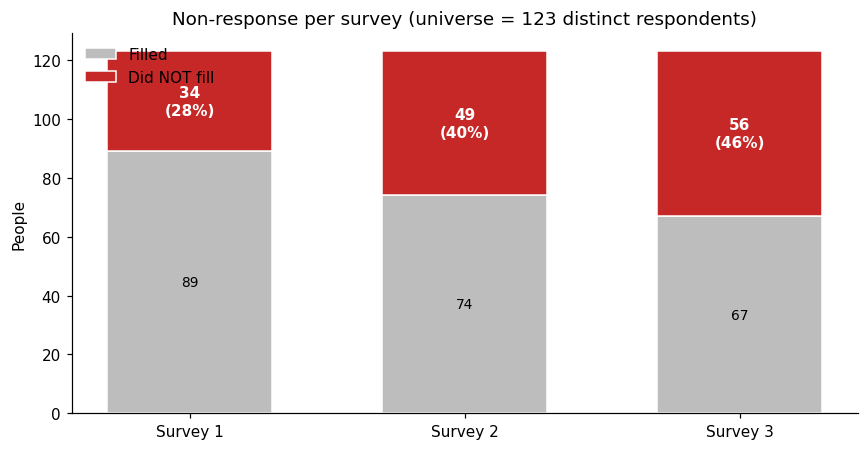

In [6]:
fig, ax = plt.subplots(figsize=(8, 4.2))
x = np.arange(3)
w = 0.6

ax.bar(x, totals['Respondents'],   w, label='Filled',       color='#BDBDBD', edgecolor='white')
ax.bar(x, totals['Did NOT fill'],  w, bottom=totals['Respondents'],
       label='Did NOT fill', color='#C62828', edgecolor='white')

for i, (filled, missed) in enumerate(zip(totals['Respondents'], totals['Did NOT fill'])):
    ax.text(i, filled + missed / 2, f'{missed}\n({missed/universe:.0%})',
            ha='center', va='center', color='white', fontweight='bold', fontsize=10)
    ax.text(i, filled / 2, f'{filled}', ha='center', va='center', color='black', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(totals.index)
ax.set_ylabel('People')
ax.set_ylim(0, universe * 1.05)
ax.set_title(f'Non-response per survey (universe = {universe} distinct respondents)')
ax.legend(frameon=False, loc='upper left')
plt.tight_layout()
plt.show()

## 4. Teamwise non-response

For each team: how many known members did NOT fill each survey.

In [7]:
team_size = master.groupby('team').size().rename('Team size')

team_missing = (~master[['in_S1', 'in_S2', 'in_S3']]).groupby(master['team']).sum()
team_missing.columns = ['Missed S1', 'Missed S2', 'Missed S3']
team_missing = team_missing.astype(int)

team_info = (mapping.set_index('team')
             .reindex(team_size.index)
             .assign(**{'Team Name': lambda d: d['Team Name'].fillna('(no mapping)'),
                        'Team Room': lambda d: d['Team Room'].fillna('(no mapping)')}))

team_table = pd.concat([team_info, team_size, team_missing], axis=1)
team_table.index.name = 'Anon Team'
team_table = team_table.sort_index()
team_table

,Team Name,Team Room,Team size,Missed S1,Missed S2,Missed S3
Anon Team,,,,,,
1,Woodmynd,1A,1,0,0,0
2,NDA_null,1B,10,4,4,4
3,Collective Voice,1C,8,2,3,2
4,PaNDA,1D,8,0,2,4
5,NU-Shift,1E,3,2,2,0
6,Scope2WBS,2A,6,0,2,3
11,Supply Wise,3A,12,6,6,6
12,The Envelope,3B,8,4,4,5
13,Route Awakening,3C,4,0,1,2


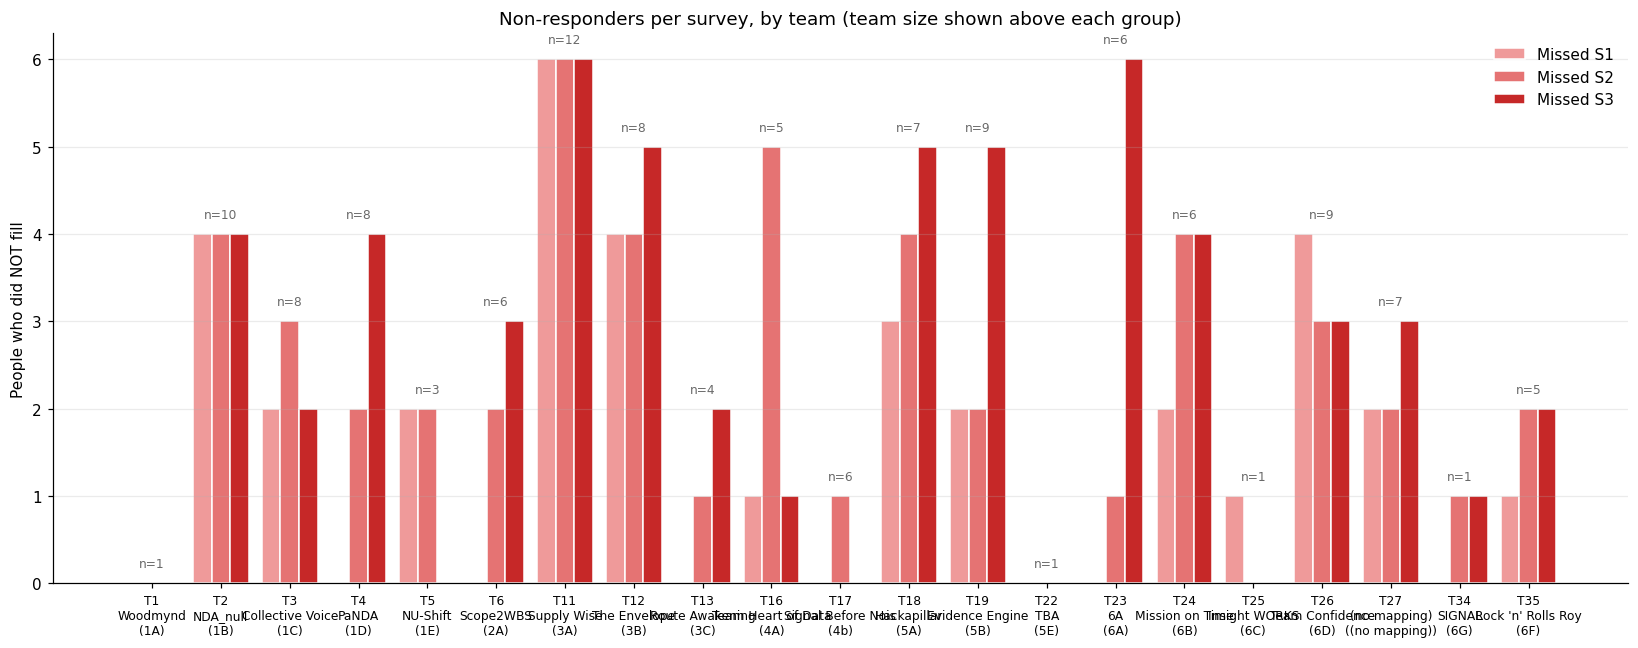

In [8]:
labels = [f"T{t}\n{team_table.loc[t, 'Team Name'][:18]}\n({team_table.loc[t, 'Team Room']})"
          for t in team_table.index]

fig, ax = plt.subplots(figsize=(15, 6))
x = np.arange(len(team_table))
w = 0.27

reds = ['#EF9A9A', '#E57373', '#C62828']
ax.bar(x - w, team_table['Missed S1'], w, label='Missed S1', color=reds[0], edgecolor='white')
ax.bar(x,     team_table['Missed S2'], w, label='Missed S2', color=reds[1], edgecolor='white')
ax.bar(x + w, team_table['Missed S3'], w, label='Missed S3', color=reds[2], edgecolor='white')

for i, (t, row) in enumerate(team_table.iterrows()):
    top = max(row['Missed S1'], row['Missed S2'], row['Missed S3'])
    ax.text(i, top + 0.15, f"n={row['Team size']}", ha='center', va='bottom',
            fontsize=8, color='dimgrey')

ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=8)
ax.set_ylabel('People who did NOT fill')
ax.set_title('Non-responders per survey, by team (team size shown above each group)')
ax.legend(frameon=False)
ax.grid(axis='y', alpha=0.25)
plt.tight_layout()
plt.show()

### Stacked view: filled vs did-not-fill per team per survey

Same data, presented so each team × survey bar shows the full team split. The red portion is the non-response; the grey portion gives the context of team size.

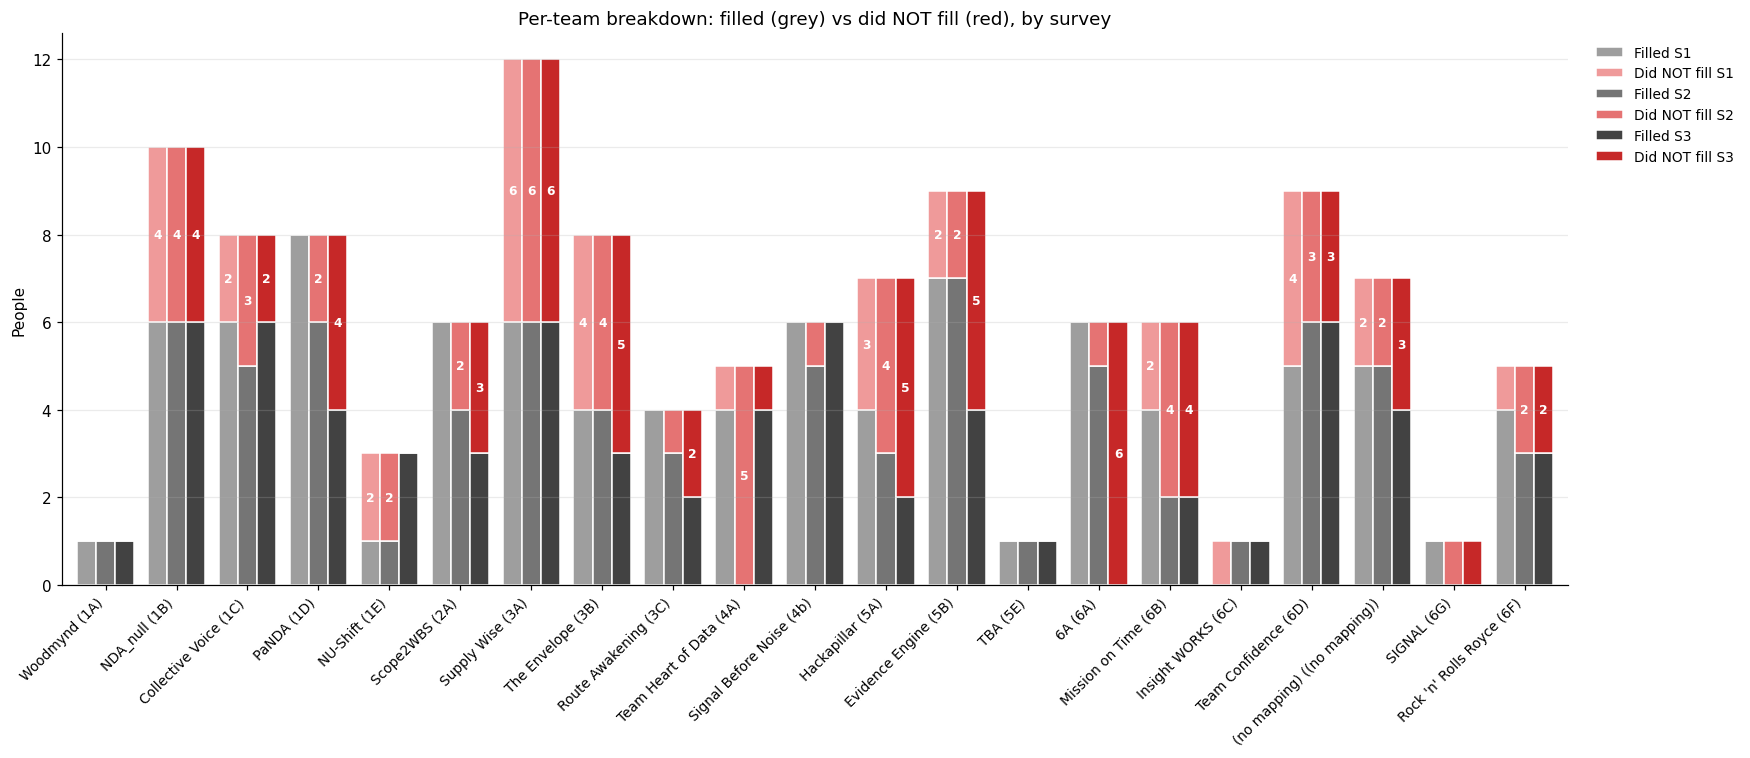

In [13]:
filled_tbl = pd.DataFrame(index=team_table.index)
filled_tbl['Filled S1'] = team_table['Team size'] - team_table['Missed S1']
filled_tbl['Filled S2'] = team_table['Team size'] - team_table['Missed S2']
filled_tbl['Filled S3'] = team_table['Team size'] - team_table['Missed S3']

# Single-line labels — rotation gives horizontal space, so we don't need to stack lines
labels = [f"{team_table.loc[t, 'Team Name']} ({team_table.loc[t, 'Team Room']})"
          for t in team_table.index]

fig, ax = plt.subplots(figsize=(16, 7))
x = np.arange(len(team_table))
w = 0.27

for i, (surv, colour_filled, colour_missed) in enumerate([
    ('S1', '#9E9E9E', '#EF9A9A'),
    ('S2', '#757575', '#E57373'),
    ('S3', '#424242', '#C62828'),
]):
    offset = (i - 1) * w
    filled = filled_tbl[f'Filled {surv}'].values
    missed = team_table[f'Missed {surv}'].values
    ax.bar(x + offset, filled, w, color=colour_filled, edgecolor='white', label=f'Filled {surv}')
    ax.bar(x + offset, missed, w, bottom=filled, color=colour_missed, edgecolor='white',
           label=f'Did NOT fill {surv}')
    # Only label the missed segment when it's tall enough to fit text comfortably (>= 2)
    for xi, (f_, m_) in enumerate(zip(filled, missed)):
        if m_ >= 2:
            ax.text(xi + offset, f_ + m_ / 2, str(m_), ha='center', va='center',
                    fontsize=8, color='white', fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=9)
ax.set_ylabel('People')
ax.set_title('Per-team breakdown: filled (grey) vs did NOT fill (red), by survey')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', frameon=False, fontsize=9)
ax.grid(axis='y', alpha=0.25)
ax.margins(x=0.01)
plt.tight_layout()
plt.show()

### Non-response rate heatmap

Fraction of each team's known members who did NOT fill each survey. Dark red = high non-response.

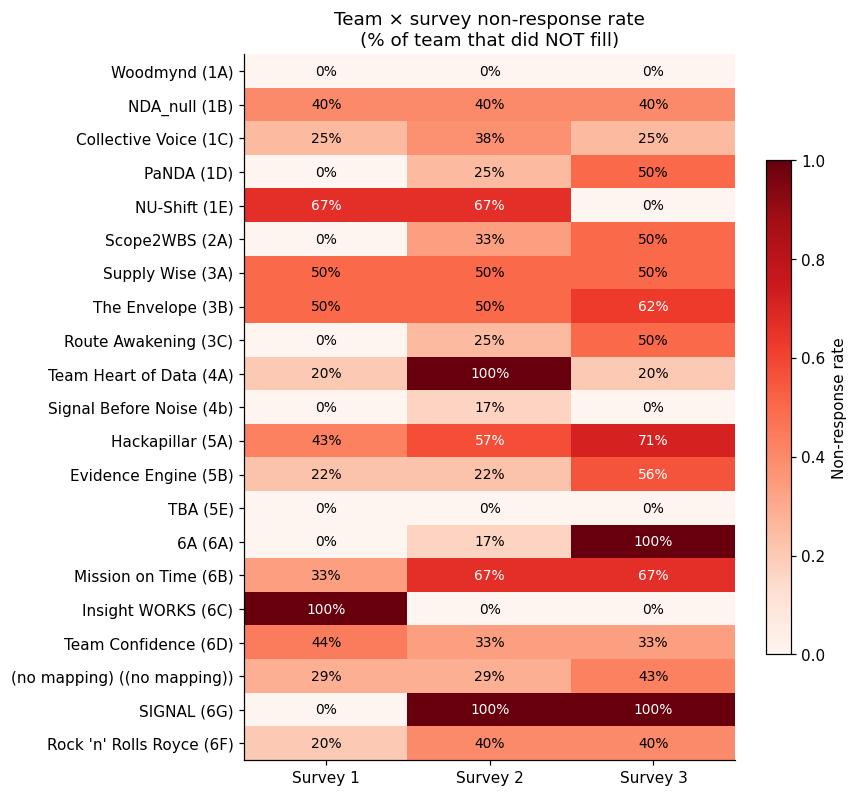

In [11]:
miss_rate = team_table[['Missed S1', 'Missed S2', 'Missed S3']].div(team_table['Team size'], axis=0)
miss_rate.columns = ['Survey 1', 'Survey 2', 'Survey 3']

row_labels = [f"{team_table.loc[t, 'Team Name'][:22]} ({team_table.loc[t, 'Team Room']})"
              for t in miss_rate.index]

fig, ax = plt.subplots(figsize=(8, max(4, 0.35 * len(miss_rate))))
im = ax.imshow(miss_rate.values, cmap='Reds', vmin=0, vmax=1, aspect='auto')

ax.set_xticks(range(3))
ax.set_xticklabels(miss_rate.columns)
ax.set_yticks(range(len(miss_rate)))
ax.set_yticklabels(row_labels)

for i in range(len(miss_rate)):
    for j in range(3):
        val = miss_rate.values[i, j]
        ax.text(j, i, f'{val:.0%}', ha='center', va='center',
                color='white' if val > 0.55 else 'black', fontsize=9)

plt.colorbar(im, ax=ax, label='Non-response rate', shrink=0.7)
ax.set_title('Team \u00d7 survey non-response rate\n(% of team that did NOT fill)')
plt.tight_layout()
plt.show()

## 5. Overlap between surveys

All seven regions of the three-way Venn.

In [14]:
s1, s2, s3 = master['in_S1'], master['in_S2'], master['in_S3']

regions = {
    'Only S1 (filled 1, not 2, not 3)':     ( s1 & ~s2 & ~s3).sum(),
    'Only S2 (filled 2, not 1, not 3)':     (~s1 &  s2 & ~s3).sum(),
    'Only S3 (filled 3, not 1, not 2)':     (~s1 & ~s2 &  s3).sum(),
    'S1 & S2 only (not S3)':                ( s1 &  s2 & ~s3).sum(),
    'S1 & S3 only (not S2)':                ( s1 & ~s2 &  s3).sum(),
    'S2 & S3 only (not S1)':                (~s1 &  s2 &  s3).sum(),
    'All three':                            ( s1 &  s2 &  s3).sum(),
}
regions_df = pd.Series(regions, name='Respondents').to_frame()
regions_df['% of universe'] = (regions_df['Respondents'] / universe * 100).round(1)
regions_df.loc['TOTAL'] = [regions_df['Respondents'].sum(), regions_df['% of universe'].sum().round(1)]
regions_df

,Respondents,% of universe
"Only S1 (filled 1, not 2, not 3)",21.0,17.1
"Only S2 (filled 2, not 1, not 3)",12.0,9.8
"Only S3 (filled 3, not 1, not 2)",19.0,15.4
S1 & S2 only (not S3),23.0,18.7
S1 & S3 only (not S2),9.0,7.3
S2 & S3 only (not S1),3.0,2.4
All three,36.0,29.3
TOTAL,123.0,100.0


In [15]:
focus = pd.Series({
    'Filled S1 but NOT S2 AND NOT S3':   ( s1 & ~s2 & ~s3).sum(),
    'Filled S1 but NOT S2 (S3 ignored)': ( s1 & ~s2).sum(),
    'Filled S1 but NOT S3 (S2 ignored)': ( s1 & ~s3).sum(),
    'Filled S2 but NOT S3':              ( s2 & ~s3).sum(),
    'Filled S2 but NOT S1':              ( s2 & ~s1).sum(),
    'Filled S3 but NOT S1':              ( s3 & ~s1).sum(),
    'Filled S3 but NOT S2':              ( s3 & ~s2).sum(),
}, name='Respondents').to_frame()
focus

,Respondents
Filled S1 but NOT S2 AND NOT S3,21
Filled S1 but NOT S2 (S3 ignored),30
Filled S1 but NOT S3 (S2 ignored),44
Filled S2 but NOT S3,35
Filled S2 but NOT S1,15
Filled S3 but NOT S1,22
Filled S3 but NOT S2,28


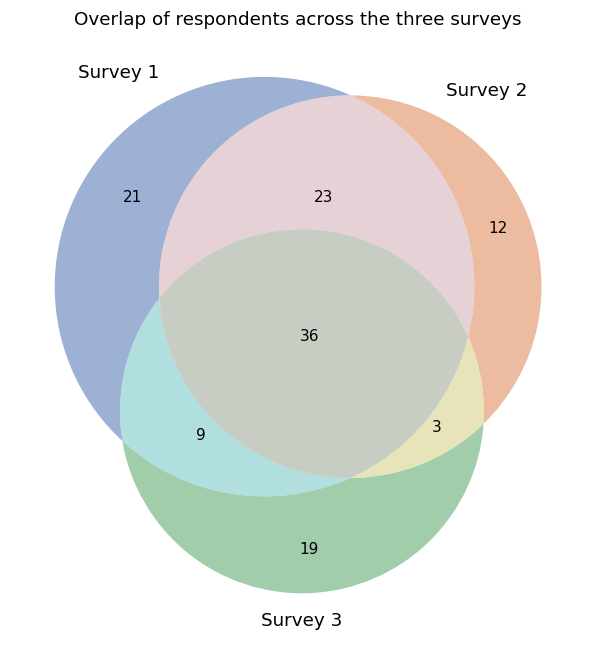

In [16]:
fig, ax = plt.subplots(figsize=(8, 6))
venn3(
    subsets=(
        regions['Only S1 (filled 1, not 2, not 3)'],
        regions['Only S2 (filled 2, not 1, not 3)'],
        regions['S1 & S2 only (not S3)'],
        regions['Only S3 (filled 3, not 1, not 2)'],
        regions['S1 & S3 only (not S2)'],
        regions['S2 & S3 only (not S1)'],
        regions['All three'],
    ),
    set_labels=('Survey 1', 'Survey 2', 'Survey 3'),
    set_colors=('#4C72B0', '#DD8452', '#55A467'),
    alpha=0.55, ax=ax,
)
ax.set_title('Overlap of respondents across the three surveys')
plt.tight_layout()
plt.show()

## 6. Per-team attrition patterns

How each team's known members break down by which surveys they missed. Green = filled all three; reds = missed one or more waves.

In [17]:
def pattern(row):
    return ''.join(['1' if row['in_S1'] else '0',
                    '1' if row['in_S2'] else '0',
                    '1' if row['in_S3'] else '0'])

master['pattern'] = master.apply(pattern, axis=1)
pattern_labels = {
    '111': 'All three',
    '110': 'Missed S3 only',
    '101': 'Missed S2 only',
    '011': 'Missed S1 only',
    '100': 'Missed S2 & S3',
    '010': 'Missed S1 & S3',
    '001': 'Missed S1 & S2',
}
master['pattern_label'] = master['pattern'].map(pattern_labels)

pivot = master.pivot_table(index='team', columns='pattern_label', values='Rater',
                           aggfunc='count', fill_value=0)
pivot = pivot.reindex(columns=[v for v in pattern_labels.values() if v in pivot.columns])

pivot_display = pivot.copy()
pivot_display.insert(0, 'Team Name', [team_table.loc[t, 'Team Name'] for t in pivot_display.index])
pivot_display.insert(1, 'Team Room', [team_table.loc[t, 'Team Room'] for t in pivot_display.index])
pivot_display

pattern_label,Team Name,Team Room,All three,Missed S3 only,Missed S2 only,Missed S1 only,Missed S2 & S3,Missed S1 & S3,Missed S1 & S2
team,,,,,,,,,
1,Woodmynd,1A,1,0,0,0,0,0,0
2,NDA_null,1B,4,0,0,0,2,2,2
3,Collective Voice,1C,3,1,2,0,0,1,1
4,PaNDA,1D,4,2,0,0,2,0,0
5,NU-Shift,1E,0,0,1,1,0,0,1
6,Scope2WBS,2A,3,1,0,0,2,0,0
11,Supply Wise,3A,2,2,0,0,2,2,4
12,The Envelope,3B,1,1,0,0,2,2,2
13,Route Awakening,3C,1,2,1,0,0,0,0


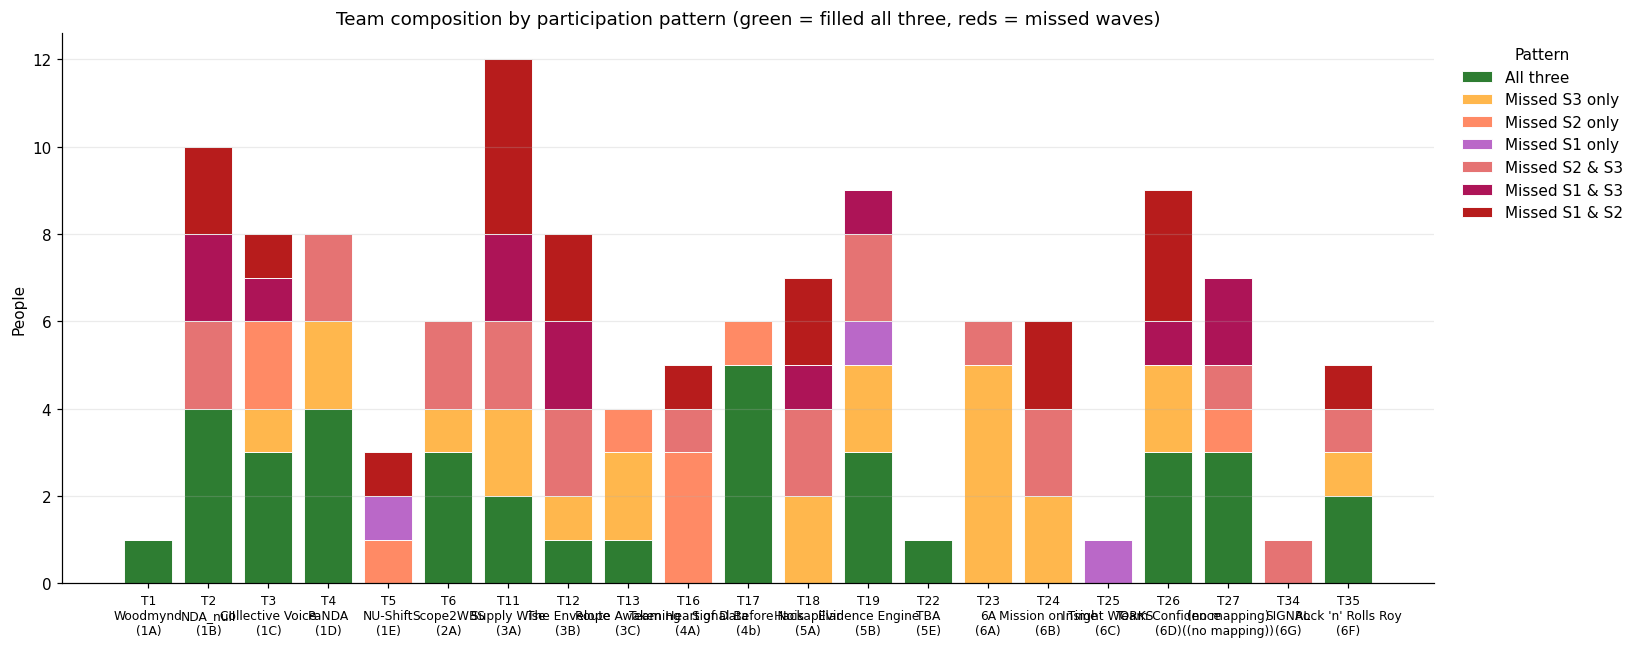

In [18]:
palette = {
    'All three':         '#2E7D32',
    'Missed S3 only':    '#FFB74D',
    'Missed S2 only':    '#FF8A65',
    'Missed S1 only':    '#BA68C8',
    'Missed S2 & S3':    '#E57373',
    'Missed S1 & S3':    '#AD1457',
    'Missed S1 & S2':    '#B71C1C',
}
plot_cols = [c for c in palette if c in pivot.columns]

labels = [f"T{t}\n{team_table.loc[t, 'Team Name'][:18]}\n({team_table.loc[t, 'Team Room']})"
          for t in pivot.index]

fig, ax = plt.subplots(figsize=(15, 6))
bottom = np.zeros(len(pivot))
x = np.arange(len(pivot))
for col in plot_cols:
    ax.bar(x, pivot[col].values, bottom=bottom, label=col,
           color=palette[col], edgecolor='white', linewidth=0.6)
    bottom += pivot[col].values

ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=8)
ax.set_ylabel('People')
ax.set_title('Team composition by participation pattern (green = filled all three, reds = missed waves)')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', frameon=False, title='Pattern')
ax.grid(axis='y', alpha=0.25)
plt.tight_layout()
plt.show()

## 7. Summary

In [19]:
lines = [
    f"Universe: {universe} distinct respondents across all three surveys",
    '',
    f"Did NOT fill Survey 1: {(~s1).sum():>3}  ({(~s1).sum()/universe:.0%} of universe)",
    f"Did NOT fill Survey 2: {(~s2).sum():>3}  ({(~s2).sum()/universe:.0%} of universe)",
    f"Did NOT fill Survey 3: {(~s3).sum():>3}  ({(~s3).sum()/universe:.0%} of universe)",
    '',
    'Overlap regions:',
    f"  Filled all three:             {( s1 &  s2 &  s3).sum()}",
    f"  Filled S1 only:               {( s1 & ~s2 & ~s3).sum()}",
    f"  Filled S2 only:               {(~s1 &  s2 & ~s3).sum()}",
    f"  Filled S3 only:               {(~s1 & ~s2 &  s3).sum()}",
    f"  Filled S1 & S2 but not S3:    {( s1 &  s2 & ~s3).sum()}",
    f"  Filled S1 & S3 but not S2:    {( s1 & ~s2 &  s3).sum()}",
    f"  Filled S2 & S3 but not S1:    {(~s1 &  s2 &  s3).sum()}",
    '',
    'Worst-performing teams by non-response rate (avg across all three surveys):',
]
avg_miss = miss_rate.mean(axis=1).sort_values(ascending=False).head(5)
for t, rate in avg_miss.items():
    name = team_table.loc[t, 'Team Name']
    room = team_table.loc[t, 'Team Room']
    lines.append(f"  T{t} {name} ({room}): {rate:.0%} avg non-response")
print('\n'.join(lines))

Universe: 123 distinct respondents across all three surveys

Did NOT fill Survey 1:  34  (28% of universe)
Did NOT fill Survey 2:  49  (40% of universe)
Did NOT fill Survey 3:  56  (46% of universe)

Overlap regions:
  Filled all three:             36
  Filled S1 only:               21
  Filled S2 only:               12
  Filled S3 only:               19
  Filled S1 & S2 but not S3:    23
  Filled S1 & S3 but not S2:    9
  Filled S2 & S3 but not S1:    3

Worst-performing teams by non-response rate (avg across all three surveys):
  T34 SIGNAL (6G): 67% avg non-response
  T18 Hackapillar (5A): 57% avg non-response
  T24 Mission on Time (6B): 56% avg non-response
  T12 The Envelope (3B): 54% avg non-response
  T11 Supply Wise (3A): 50% avg non-response


## 8. Export

In [20]:
master.to_csv('respondent_participation.csv', index=False)
team_table.to_csv('team_non_response_counts.csv')
pivot_display.to_csv('team_participation_patterns.csv')
print('Wrote: respondent_participation.csv, team_non_response_counts.csv, team_participation_patterns.csv')

Wrote: respondent_participation.csv, team_non_response_counts.csv, team_participation_patterns.csv


,Day,Participants,Filled,Did NOT fill,Response rate
Survey 1,Day 1,112,89,23,79%
Survey 2,Day 1,112,74,38,66%
Survey 3,Day 2,108,67,41,62%


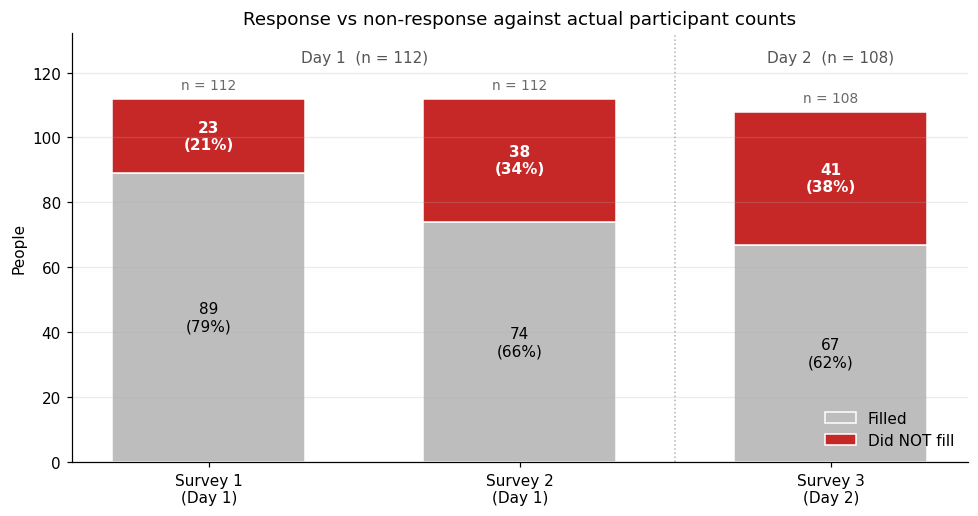

In [24]:
# --- Response vs true participant counts (Day 1 and Day 3) ---
# S1 and S2 were on Day 1 with 112 participants in the room.
# S3 was on Day 3 with 108 participants.

PARTICIPANTS = {'S1': 112, 'S2': 112, 'S3': 108}
DAY = {'S1': 'Day 1', 'S2': 'Day 1', 'S3': 'Day 2'}

resp = {k: surveys[k]['Rater'].nunique() for k in ['S1', 'S2', 'S3']}
miss = {k: PARTICIPANTS[k] - resp[k] for k in resp}
rate = {k: resp[k] / PARTICIPANTS[k] for k in resp}

summary = pd.DataFrame({
    'Day':          [DAY[k] for k in ['S1', 'S2', 'S3']],
    'Participants': [PARTICIPANTS[k] for k in ['S1', 'S2', 'S3']],
    'Filled':       [resp[k] for k in ['S1', 'S2', 'S3']],
    'Did NOT fill': [miss[k] for k in ['S1', 'S2', 'S3']],
    'Response rate':[f'{rate[k]:.0%}' for k in ['S1', 'S2', 'S3']],
}, index=['Survey 1', 'Survey 2', 'Survey 3'])
display(summary)

fig, ax = plt.subplots(figsize=(9, 4.8))
x = np.arange(3)
w = 0.62
labels = ['Survey 1\n(Day 1)', 'Survey 2\n(Day 1)', 'Survey 3\n(Day 2)']

filled_vals = [resp[k] for k in ['S1', 'S2', 'S3']]
missed_vals = [miss[k] for k in ['S1', 'S2', 'S3']]
denom_vals  = [PARTICIPANTS[k] for k in ['S1', 'S2', 'S3']]

ax.bar(x, filled_vals, w, color='#BDBDBD', edgecolor='white', label='Filled')
ax.bar(x, missed_vals, w, bottom=filled_vals, color='#C62828', edgecolor='white', label='Did NOT fill')

for i, (f_, m_, n_) in enumerate(zip(filled_vals, missed_vals, denom_vals)):
    ax.text(i, f_ / 2, f'{f_}\n({f_/n_:.0%})',
            ha='center', va='center', fontsize=10, color='black')
    ax.text(i, f_ + m_ / 2, f'{m_}\n({m_/n_:.0%})',
            ha='center', va='center', fontsize=10, color='white', fontweight='bold')
    ax.text(i, n_ + 2, f'n = {n_}', ha='center', va='bottom', fontsize=9, color='dimgrey')

# Visual separator between the two days (after S2)
ax.axvline(1.5, color='grey', linestyle=':', linewidth=1, alpha=0.6)
ax.text(0.5, max(denom_vals) * 1.1, 'Day 1  (n = 112)', ha='center', fontsize=10, color='#555')
ax.text(2.0, max(denom_vals) * 1.1, 'Day 2  (n = 108)', ha='center', fontsize=10, color='#555')

ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel('People')
ax.set_ylim(0, max(denom_vals) * 1.18)
ax.set_title('Response vs non-response against actual participant counts')
ax.legend(frameon=False, loc='lower right')
ax.grid(axis='y', alpha=0.25)
plt.tight_layout()
plt.show()

In [25]:
# Team-level scores from Survey 1 respondents, used as a BASELINE.
# Rationale: S1 is the earliest wave, so these values are a "before" snapshot
# that precedes most of the non-response events in S2 and S3. Averaging over
# the team's S1 respondents reduces individual noise.

S1_WELL = 'Wellbeing'
S1_COG  = 'My level of <b>cognitive</b> load&nbsp;'

s1_raw = surveys['S1'][['Rater', 'team', S1_WELL, S1_COG]].copy()
s1_raw[S1_WELL] = pd.to_numeric(s1_raw[S1_WELL], errors='coerce')
s1_raw[S1_COG]  = pd.to_numeric(s1_raw[S1_COG],  errors='coerce')

team_scores = s1_raw.groupby('team').agg(
    s1_wellbeing_mean=(S1_WELL, 'mean'),
    s1_cogload_mean=(S1_COG, 'mean'),
    s1_n=(S1_WELL, 'count'),
).round(2)

# Merge with non-response counts and mapping
team_analysis = team_table.join(team_scores, how='left')
team_analysis['Non-response rate S2'] = (team_analysis['Missed S2'] / team_analysis['Team size']).round(3)
team_analysis['Non-response rate S3'] = (team_analysis['Missed S3'] / team_analysis['Team size']).round(3)
team_analysis['Challenge'] = team_analysis.index.map(
    mapping.set_index('team')['Challenge Number'] if 'Challenge Number' in mapping.columns
    else mapping_raw.set_index('Anon Team')['Challenge Number']
).astype('Int64')

team_analysis[['Team Name', 'Team Room', 'Challenge', 'Team size',
               's1_wellbeing_mean', 's1_cogload_mean', 's1_n',
               'Missed S2', 'Missed S3',
               'Non-response rate S2', 'Non-response rate S3']]

,Team Name,Team Room,Challenge,Team size,s1_wellbeing_mean,s1_cogload_mean,s1_n,Missed S2,Missed S3,Non-response rate S2,Non-response rate S3
Anon Team,,,,,,,,,,,
1,Woodmynd,1A,1,1,78.00,58.00,1.0,0,0,0.000,0.000
2,NDA_null,1B,1,10,48.50,64.00,6.0,4,4,0.400,0.400
3,Collective Voice,1C,1,8,76.33,69.17,6.0,3,2,0.375,0.250
4,PaNDA,1D,1,8,55.88,56.50,8.0,2,4,0.250,0.500
5,NU-Shift,1E,5,3,90.00,67.00,1.0,2,0,0.667,0.000
6,Scope2WBS,2A,2,6,53.67,74.00,6.0,2,3,0.333,0.500
11,Supply Wise,3A,3,12,57.83,56.50,6.0,6,6,0.500,0.500
12,The Envelope,3B,3,8,84.25,72.00,4.0,4,5,0.500,0.625
13,Route Awakening,3C,3,4,79.75,63.50,4.0,1,2,0.250,0.500


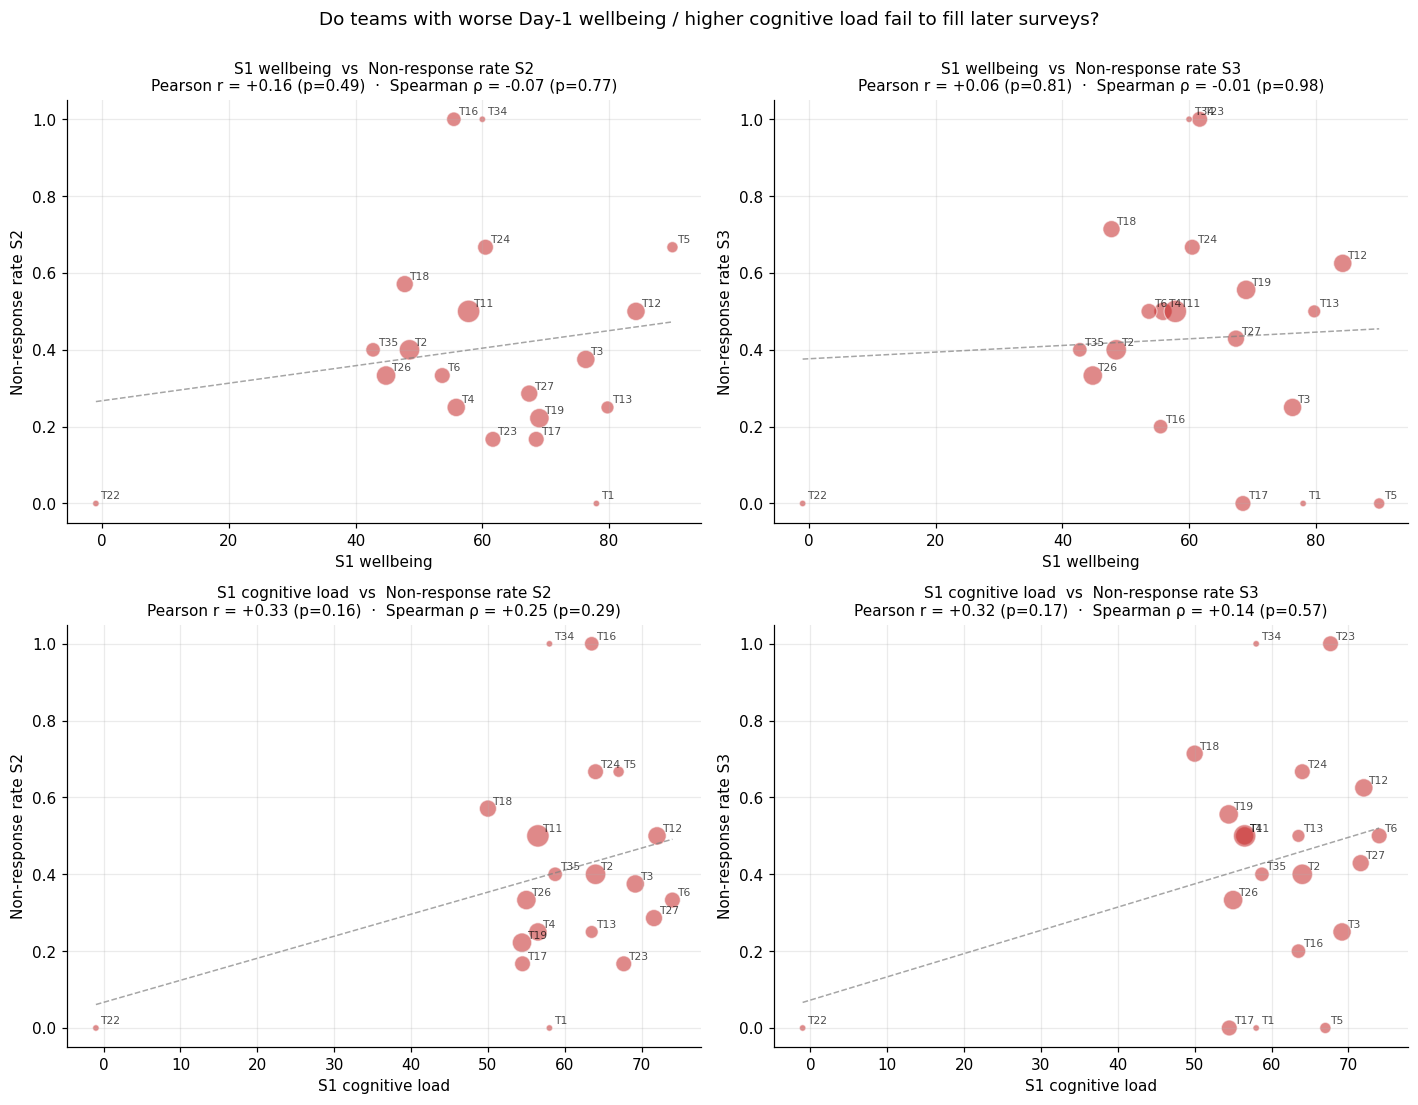


Teams in analysis: 20 (dot size = team size)

Caveats:
  · Wellbeing / cognitive load are means over S1 *respondents* only — we cannot
    measure these for people who never filled any survey.
  · With n=20 teams, only very strong correlations (|r| > ~0.55)
    will reach p < 0.05. Treat weak correlations as suggestive, not conclusive.


In [26]:
from scipy import stats

# Drop teams where we don't have an S1 baseline (nobody from that team filled S1)
corr_df = team_analysis.dropna(subset=['s1_wellbeing_mean', 's1_cogload_mean']).copy()

pairs = [
    ('s1_wellbeing_mean', 'Non-response rate S2', 'S1 wellbeing',     'Non-response rate S2'),
    ('s1_wellbeing_mean', 'Non-response rate S3', 'S1 wellbeing',     'Non-response rate S3'),
    ('s1_cogload_mean',   'Non-response rate S2', 'S1 cognitive load','Non-response rate S2'),
    ('s1_cogload_mean',   'Non-response rate S3', 'S1 cognitive load','Non-response rate S3'),
]

fig, axes = plt.subplots(2, 2, figsize=(13, 10))
for ax, (xcol, ycol, xlab, ylab) in zip(axes.flat, pairs):
    d = corr_df[[xcol, ycol, 'Team size']].dropna()
    x_vals = d[xcol].values
    y_vals = d[ycol].values

    # Pearson (linear) and Spearman (rank) — report both, they answer slightly different questions
    r_p, p_p = stats.pearsonr(x_vals, y_vals)
    r_s, p_s = stats.spearmanr(x_vals, y_vals)

    # Scatter, point size proportional to team size
    ax.scatter(x_vals, y_vals, s=d['Team size'] * 18, alpha=0.55,
               color='#C62828', edgecolor='white', linewidth=0.8)

    # Label each team
    for t, row in d.iterrows():
        ax.annotate(f'T{t}', (row[xcol], row[ycol]),
                    fontsize=7, alpha=0.7, xytext=(3, 3), textcoords='offset points')

    # Best-fit line
    if len(x_vals) >= 3:
        slope, intercept = np.polyfit(x_vals, y_vals, 1)
        xs = np.linspace(x_vals.min(), x_vals.max(), 50)
        ax.plot(xs, slope * xs + intercept, color='grey', linestyle='--', linewidth=1, alpha=0.7)

    ax.set_xlabel(xlab)
    ax.set_ylabel(ylab)
    ax.set_title(f'{xlab}  vs  {ylab}\n'
                 f'Pearson r = {r_p:+.2f} (p={p_p:.2f})  ·  Spearman ρ = {r_s:+.2f} (p={p_s:.2f})',
                 fontsize=10)
    ax.grid(alpha=0.25)

plt.suptitle('Do teams with worse Day-1 wellbeing / higher cognitive load fail to fill later surveys?',
             fontsize=12, y=1.00)
plt.tight_layout()
plt.show()

print(f'\nTeams in analysis: {len(corr_df)} (dot size = team size)')
print('\nCaveats:')
print('  · Wellbeing / cognitive load are means over S1 *respondents* only — we cannot')
print('    measure these for people who never filled any survey.')
print(f'  · With n={len(corr_df)} teams, only very strong correlations (|r| > ~0.55)')
print('    will reach p < 0.05. Treat weak correlations as suggestive, not conclusive.')

Teams per challenge:
  Challenge 1: 4 team(s)
  Challenge 2: 1 team(s)
  Challenge 3: 3 team(s)
  Challenge 4: 2 team(s)
  Challenge 5: 4 team(s)
  Challenge 6: 6 team(s)


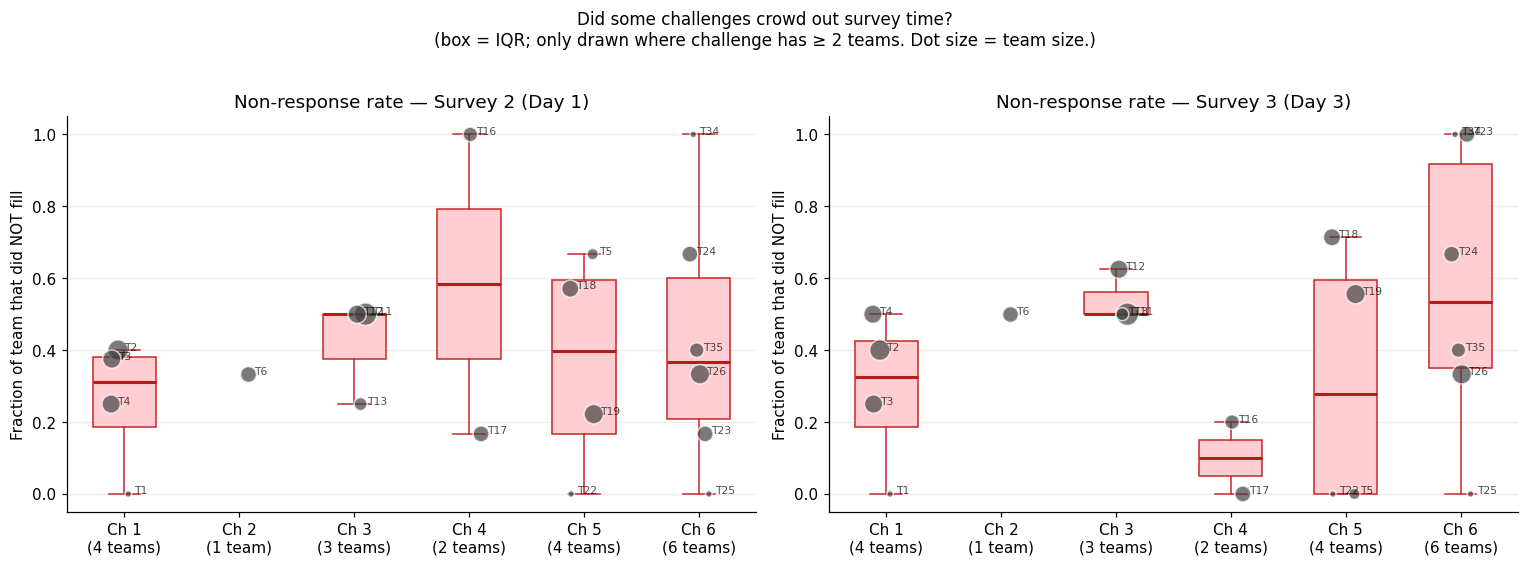

Kruskal-Wallis across challenges — S2 non-response: H=1.03, p=0.906
Kruskal-Wallis across challenges — S3 non-response: H=4.47, p=0.347


In [27]:
# Challenge is categorical (6 groups, uneven team counts) — comparison not correlation.
# Boxplot + individual team points for transparency.

challenge_counts = team_analysis['Challenge'].value_counts().sort_index()
print('Teams per challenge:')
for c, n in challenge_counts.items():
    print(f'  Challenge {c}: {n} team(s)')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, ycol, title in [
    (axes[0], 'Non-response rate S2', 'Non-response rate — Survey 2 (Day 1)'),
    (axes[1], 'Non-response rate S3', 'Non-response rate — Survey 3 (Day 3)'),
]:
    d = team_analysis[['Challenge', ycol, 'Team size']].dropna()
    challenges = sorted(d['Challenge'].unique())
    data_by_ch = [d.loc[d['Challenge'] == c, ycol].values for c in challenges]

    # Box only where we have enough teams to form one (>= 2)
    bp_data  = [vals for vals, c in zip(data_by_ch, challenges) if len(vals) >= 2]
    bp_pos   = [i for i, (vals, c) in enumerate(zip(data_by_ch, challenges)) if len(vals) >= 2]
    if bp_data:
        ax.boxplot(bp_data, positions=bp_pos, widths=0.55, patch_artist=True,
                   boxprops=dict(facecolor='#FFCDD2', edgecolor='#C62828'),
                   medianprops=dict(color='#B71C1C', linewidth=2),
                   whiskerprops=dict(color='#C62828'),
                   capprops=dict(color='#C62828'),
                   flierprops=dict(marker='o', markerfacecolor='#C62828', markersize=4))

    # Always show individual team points (jittered), sized by team size
    rng = np.random.default_rng(0)
    for i, (vals, c) in enumerate(zip(data_by_ch, challenges)):
        if len(vals) == 0:
            continue
        sizes = d.loc[d['Challenge'] == c, 'Team size'].values * 18
        jitter = rng.uniform(-0.12, 0.12, size=len(vals))
        ax.scatter(np.full(len(vals), i) + jitter, vals, s=sizes,
                   color='#424242', alpha=0.7, edgecolor='white', zorder=3)
        # Team labels
        teams_here = d.loc[d['Challenge'] == c].index.tolist()
        for xj, yj, tj in zip(np.full(len(vals), i) + jitter, vals, teams_here):
            ax.annotate(f'T{tj}', (xj, yj), fontsize=7, alpha=0.7,
                        xytext=(4, 0), textcoords='offset points')

    ax.set_xticks(range(len(challenges)))
    ax.set_xticklabels([f'Ch {c}\n({challenge_counts[c]} team{"s" if challenge_counts[c] > 1 else ""})'
                        for c in challenges])
    ax.set_ylabel('Fraction of team that did NOT fill')
    ax.set_title(title)
    ax.set_ylim(-0.05, 1.05)
    ax.grid(axis='y', alpha=0.25)

plt.suptitle('Did some challenges crowd out survey time?\n'
             '(box = IQR; only drawn where challenge has ≥ 2 teams. Dot size = team size.)',
             fontsize=11, y=1.02)
plt.tight_layout()
plt.show()

# Formal test: Kruskal-Wallis (non-parametric ANOVA) across challenges with >= 2 teams
from scipy.stats import kruskal
for ycol, label in [('Non-response rate S2', 'S2'), ('Non-response rate S3', 'S3')]:
    groups = [team_analysis.loc[team_analysis['Challenge'] == c, ycol].dropna().values
              for c in sorted(team_analysis['Challenge'].dropna().unique())]
    groups = [g for g in groups if len(g) >= 2]
    if len(groups) >= 2:
        h, p = kruskal(*groups)
        print(f'Kruskal-Wallis across challenges — {label} non-response: H={h:.2f}, p={p:.3f}')

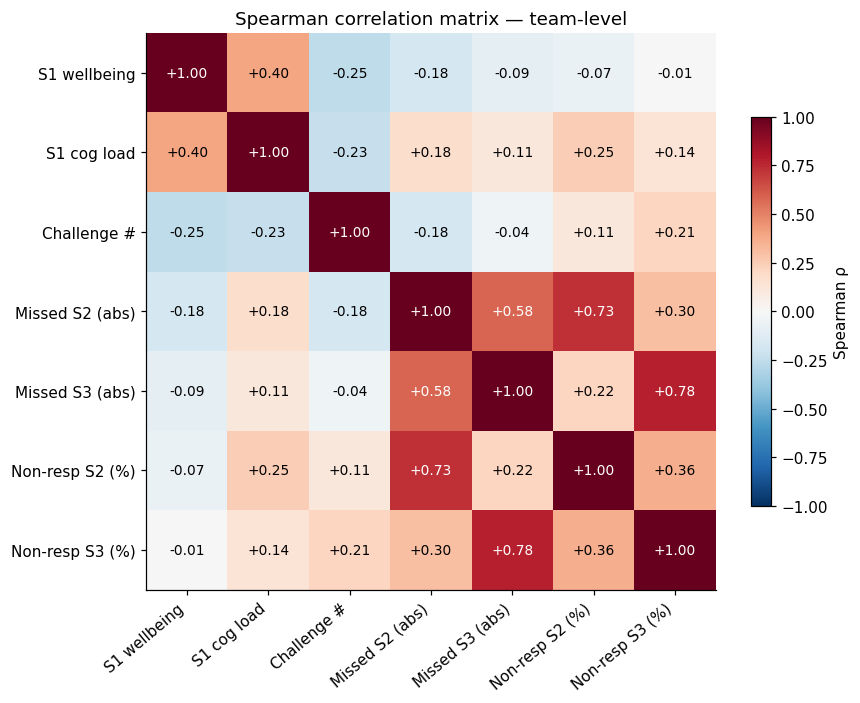


Interpretation guide:
  Spearman ρ > 0: teams with higher X tend to have higher Y (rank-wise)
  |ρ| < 0.3   weak    · 0.3-0.5 moderate · > 0.5 strong
  With n ≈ 19 teams, ρ needs to be ~|0.43|+ for p < 0.05


In [28]:
# Everything together in one heatmap for quick reference
corr_vars = team_analysis[['s1_wellbeing_mean', 's1_cogload_mean', 'Challenge',
                           'Missed S2', 'Missed S3',
                           'Non-response rate S2', 'Non-response rate S3']].copy()
corr_vars = corr_vars.rename(columns={
    's1_wellbeing_mean': 'S1 wellbeing',
    's1_cogload_mean':   'S1 cog load',
    'Challenge':         'Challenge #',
    'Missed S2':         'Missed S2 (abs)',
    'Missed S3':         'Missed S3 (abs)',
    'Non-response rate S2': 'Non-resp S2 (%)',
    'Non-response rate S3': 'Non-resp S3 (%)',
})

# Spearman — more robust to outliers and handles the ordinal Challenge # more honestly
corr = corr_vars.corr(method='spearman')

fig, ax = plt.subplots(figsize=(8, 6.5))
im = ax.imshow(corr.values, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
ax.set_xticks(range(len(corr))); ax.set_xticklabels(corr.columns, rotation=40, ha='right')
ax.set_yticks(range(len(corr))); ax.set_yticklabels(corr.index)
for i in range(len(corr)):
    for j in range(len(corr)):
        v = corr.values[i, j]
        if not np.isnan(v):
            ax.text(j, i, f'{v:+.2f}', ha='center', va='center',
                    color='white' if abs(v) > 0.55 else 'black', fontsize=9)
plt.colorbar(im, ax=ax, label='Spearman ρ', shrink=0.7)
ax.set_title('Spearman correlation matrix — team-level')
plt.tight_layout()
plt.show()

print('\nInterpretation guide:')
print('  Spearman ρ > 0: teams with higher X tend to have higher Y (rank-wise)')
print('  |ρ| < 0.3   weak    · 0.3-0.5 moderate · > 0.5 strong')
print(f'  With n ≈ {len(corr_vars.dropna())} teams, ρ needs to be ~|0.43|+ for p < 0.05')